# AION-ARC v2.1 — 100% target (UNVERIFIED)\n\n# Tufa Labs ARC3 submission

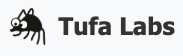

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## AION-ARC v2.1 — ASTRA/TARDIGRADE competition overlay

This version adds executable prediction gates around live actions, HUD-resistant gameplay signatures, NO-REPEAT protection for inert probes, evidence summaries, and optional ACTION7 rollback verification. It reuses the public Duck harness as the offline local-model execution base while keeping Kaggle hidden-score claims fail-closed.


In [ ]:
# AION-ARC v2.1 — TARDIGRADE / evidence / prediction execution overlay
import shutil
import sys
from pathlib import Path

AION_SENTINEL = "AION_VERIFICATION_ADDENDUM"
AION_SANDBOX_SENTINEL = 'AION_GUARD_VERSION = "2.1"'
overlay_root = WORKING_DIR / "aion_arc_v21_overlay"
if overlay_root.exists():
    shutil.rmtree(overlay_root)

tool_candidates = sorted((BUNDLE_DIR / "src").rglob("inference/agent/tool_agent.py"))
if not tool_candidates:
    raise RuntimeError("AION v2.1: Duck tool_agent.py not found.")
tool_src = tool_candidates[0]
import_root = next((p for p in tool_src.parents if (p / "inference").is_dir()), None)
if import_root is None:
    raise RuntimeError("AION v2.1: could not resolve Duck import root.")

shutil.copytree(import_root, overlay_root)
prompts_path = overlay_root / "inference" / "agent" / "prompts.py"
tool_path = overlay_root / "inference" / "agent" / "tool_agent.py"
sandbox_path = overlay_root / "inference" / "agent" / "python_tool_sandbox.py"

addendum = r'''
AION_VERIFICATION_ADDENDUM = (
    "\n\nAION-ARC v2.1 / ASTRA evidence protocol:\n"
    "- MYTHOS ASTRA Ω: evidence first -> act -> adversarial audit -> correction -> verification². Never infer PASS from a plausible-looking board.\n"
    "- BRICK PROOF GATE Ω: every claimed mechanic needs an observable success criterion and a falsifier. Maintain CONFIRMED/CANDIDATE/UNKNOWN, not vibes.\n"
    "- NO-REPEAT Ω: call aion_plan_audit(...) before acting. A repeated gameplay-inert probe requires an explicit new reason; do not burn actions by looping.\n"
    "- TARDIGRADE Ω: use checkpoints conceptually. For risky reversible probes, add rollback_on_mismatch=True; the runtime will attempt ACTION7 and verify whether the gameplay signature returned to the checkpoint.\n"
    "- Outcome learning: use aion_evidence(transitions) to learn from BOTH successful and failed actions. Preserve cross-level rules only when evidence survives new levels.\n"
    "- Retrodict before live probing. Use compact gameplay signatures that ignore likely edge HUD/timer strips.\n"
    "- Every multi-action plan should carry machine-checkable expectations where possible: expect_change, expect_level_completed, expect_reward_min, expect_valid_actions_contains, or expect_level.\n"
    "- The patched action(actions) executes batches one action at a time and aborts the remaining plan on the first prediction mismatch or terminal transition.\n"
    "- If a mismatch occurs and rollback_on_mismatch=True, ACTION7 is attempted only when available; aion_rollback_verified reports whether the gameplay signature returned exactly to the pre-action checkpoint.\n"
    "- Use hypothesis tournaments: keep multiple candidate mechanics alive when evidence is ambiguous, score them against recorded transitions, and spend a live action only when history cannot discriminate.\n"
    "- After ~20 non-progress actions on one level, stop broad probing. Build a compact executable transition model, verify it retrodicts known transitions, then do bounded BFS/DFS/beam search.\n"
    "- ZERO-COST/LOCAL-FIRST: no external API or Internet assumption; all reasoning must work inside the Kaggle offline runtime.\n"
    "\nAION sandbox helpers available in python:\n"
    "- aion_frame_signature(frame): HUD-resistant gameplay signature.\n"
    "- aion_evidence(transitions, limit=12): compact success/failure ledger.\n"
    "- aion_plan_audit(plan, valid_actions, transitions, last_action_result): warnings before execution.\n"
    "- action([...]) supports per-step metadata: expect_change, expect_level_completed, expect_reward_min, expect_valid_actions_contains, expect_level, rollback_on_mismatch, force_probe, hypothesis.\n"
)
'''

ptext = prompts_path.read_text()
if AION_SENTINEL not in ptext:
    prompts_path.write_text(ptext.rstrip() + "\n\n" + addendum.lstrip())

ttext = tool_path.read_text()
if "AION_VERIFICATION_ADDENDUM," not in ttext:
    anchor = "    VISUAL_GAME_ADDENDUM,\n)"
    if anchor not in ttext:
        raise RuntimeError("AION v2.1: prompt import anchor changed.")
    ttext = ttext.replace(anchor, "    VISUAL_GAME_ADDENDUM,\n    AION_VERIFICATION_ADDENDUM,\n)", 1)
if "prompt += AION_VERIFICATION_ADDENDUM" not in ttext:
    anchor = "    prompt += PYTHON_ADDENDUM\n"
    if anchor not in ttext:
        raise RuntimeError("AION v2.1: system-prompt anchor changed.")
    ttext = ttext.replace(anchor, anchor + "    prompt += AION_VERIFICATION_ADDENDUM\n", 1)
tool_path.write_text(ttext)

stext = sandbox_path.read_text()
if AION_SANDBOX_SENTINEL not in stext:
    guard = r'''    AION_GUARD_VERSION = "2.1"
    
    def _aion_bbox(boundary):
        pts = list(boundary or [])
        if not pts:
            return None
        rows = [int(p[0]) for p in pts]
        cols = [int(p[1]) for p in pts]
        return (min(rows), min(cols), max(rows), max(cols))
    
    def aion_probable_hud(node, shape):
        rows, cols = tuple(shape or (0, 0))
        bbox = _aion_bbox(node.get("boundary", []))
        if not bbox or rows <= 0 or cols <= 0:
            return False
        r0, c0, r1, c1 = bbox
        height = r1 - r0 + 1
        width = c1 - c0 + 1
        touches_edge = r0 == 0 or c0 == 0 or r1 == rows - 1 or c1 == cols - 1
        long_edge_strip = (width >= max(8, int(cols * 0.75)) and height <= 3) or (height >= max(8, int(rows * 0.75)) and width <= 3)
        return bool(touches_edge and long_edge_strip)
    
    def aion_frame_signature(frame):
        if frame is None:
            return ()
        seg = getattr(frame, "segmentation", {}) or {}
        shape = getattr(frame, "shape", (0, 0))
        nodes = []
        for node in seg.get("nodes", []):
            if aion_probable_hud(node, shape):
                continue
            bbox = _aion_bbox(node.get("boundary", []))
            dims = None if bbox is None else (bbox[2] - bbox[0] + 1, bbox[3] - bbox[1] + 1)
            nodes.append((
                str(node.get("color", "")),
                str(node.get("hash", "")),
                int(node.get("pixels", 0) or 0),
                dims,
                len(node.get("children", []) or []),
            ))
        return tuple(sorted(nodes))
    
    def aion_evidence(transitions, limit=12):
        rows = []
        for tr in list(transitions or [])[-max(1, int(limit)):]:
            before = aion_frame_signature(getattr(tr, "before_frame", None))
            after = aion_frame_signature(getattr(tr, "after_frame", None))
            result = getattr(tr, "result", {}) or {}
            rows.append({
                "action": str(getattr(tr, "action", "")),
                "gameplay_changed": before != after,
                "board_changed": bool(result.get("board_changed", False)),
                "level_completed": bool(result.get("level_completed", False)),
                "game_over": bool(result.get("game_over", False)),
                "reward": result.get("reward"),
            })
        return rows
    
    def aion_plan_audit(plan, valid_actions, transitions=None, last_action_result=None):
        valid = {str(x).upper() for x in (valid_actions or [])}
        warnings = []
        plan = list(plan or [])
        for i, item in enumerate(plan):
            spec = {"action": item} if isinstance(item, str) else dict(item or {})
            action_name = str(spec.get("action", "")).upper()
            if not action_name:
                warnings.append(f"step {i+1}: missing action")
                continue
            if valid and action_name not in valid:
                warnings.append(f"step {i+1}: {action_name} not currently valid")
            if action_name == "RESET" and "ACTION7" in valid:
                warnings.append(f"step {i+1}: RESET while ACTION7 is available")
        ev = aion_evidence(transitions or [], limit=3)
        if plan and ev:
            first = plan[0] if isinstance(plan[0], str) else str((plan[0] or {}).get("action", ""))
            last = ev[-1]
            if str(first).upper() == str(last.get("action", "")).upper() and not last.get("gameplay_changed") and not bool(last.get("level_completed")):
                warnings.append("first action repeats the latest gameplay-inert probe; justify with force_probe")
        return warnings
    
    def aion_expectation_mismatches(spec, action_result, frame):
        spec = dict(spec or {})
        result = dict(action_result or {})
        mismatches = []
        if "expect_change" in spec:
            actual = bool(result.get("board_changed", False))
            if actual != bool(spec.get("expect_change")):
                mismatches.append(f"expect_change={bool(spec.get('expect_change'))} actual={actual}")
        if "expect_level_completed" in spec:
            actual = bool(result.get("level_completed", False))
            if actual != bool(spec.get("expect_level_completed")):
                mismatches.append(f"expect_level_completed={bool(spec.get('expect_level_completed'))} actual={actual}")
        if "expect_reward_min" in spec:
            reward = result.get("reward")
            try:
                reward_value = float(reward)
                if reward_value < float(spec.get("expect_reward_min")):
                    mismatches.append(f"reward {reward_value} < {float(spec.get('expect_reward_min'))}")
            except (TypeError, ValueError):
                mismatches.append("reward unavailable for expect_reward_min")
        required = spec.get("expect_valid_actions_contains")
        if required:
            actual_valid = {str(x).upper() for x in result.get("valid_actions", [])}
            missing = [str(x).upper() for x in required if str(x).upper() not in actual_valid]
            if missing:
                mismatches.append("missing valid actions: " + ",".join(missing))
        if "expect_level" in spec and frame is not None:
            actual_level = int(getattr(frame, "level", -1))
            if actual_level != int(spec.get("expect_level")):
                mismatches.append(f"expect_level={int(spec.get('expect_level'))} actual={actual_level}")
        return mismatches
    
'''
    anchor = "    def main():\n"
    if anchor not in stext:
        raise RuntimeError("AION v2.1: sandbox main anchor changed.")
    stext = stext.replace(anchor, guard + "\n" + anchor, 1)

meta_anchor = '''                if "col" in item:
                    entry["col"] = item.get("col")
                normalized.append(entry)
'''
meta_repl = '''                if "col" in item:
                    entry["col"] = item.get("col")
                for meta_key in (
                    "expect_change",
                    "expect_level_completed",
                    "expect_reward_min",
                    "expect_valid_actions_contains",
                    "expect_level",
                    "rollback_on_mismatch",
                    "force_probe",
                    "hypothesis",
                ):
                    if meta_key in item:
                        entry[meta_key] = item.get(meta_key)
                normalized.append(entry)
'''
if meta_anchor not in stext:
    raise RuntimeError("AION v2.1: action metadata anchor changed.")
stext = stext.replace(meta_anchor, meta_repl, 1)

old_action = '''        def action(actions):
            normalized_actions = _normalize_actions(actions)
            _send({"type": "action", "actions": normalized_actions})
            reply = _recv()
            if reply.get("type") == "action_error":
                raise RuntimeError(str(reply.get("error", "action failed")))
            if reply.get("type") != "action_result":
                raise RuntimeError("Invalid action response from sandbox host.")
            action_result = reply.get("action_result") or {}
            action_results.append(action_result)
            _refresh_state(reply.get("state") or {})
            return action_result

        runtime_globals["action"] = action
'''
new_action = '''        def action(actions):
            normalized_actions = _normalize_actions(actions)
            last_result = {}
            for spec in normalized_actions:
                warnings = aion_plan_audit(
                    [spec],
                    runtime_globals.get("valid_actions", []),
                    runtime_globals.get("transitions", []),
                    runtime_globals.get("last_action_result", {}),
                )
                inert_warning = any("inert" in str(w).lower() for w in warnings)
                if inert_warning and not bool(spec.get("force_probe", False)):
                    return {
                        "aion_blocked": True,
                        "aion_reason": "repeated gameplay-inert probe; revise hypothesis or set force_probe=True",
                        "aion_warnings": warnings,
                    }

                host_spec = {k: spec[k] for k in ("action", "row", "col") if k in spec}
                pre_frame = runtime_globals.get("current_frame")
                pre_signature = aion_frame_signature(pre_frame)

                _send({"type": "action", "actions": [host_spec]})
                reply = _recv()
                if reply.get("type") == "action_error":
                    raise RuntimeError(str(reply.get("error", "action failed")))
                if reply.get("type") != "action_result":
                    raise RuntimeError("Invalid action response from sandbox host.")

                raw_result = reply.get("action_result") or {}
                _refresh_state(reply.get("state") or {})
                last_result = dict(raw_result)
                mismatches = aion_expectation_mismatches(
                    spec,
                    last_result,
                    runtime_globals.get("current_frame"),
                )
                if warnings:
                    last_result["aion_warnings"] = warnings
                if spec.get("hypothesis"):
                    last_result["aion_hypothesis"] = str(spec.get("hypothesis"))

                if mismatches:
                    last_result["aion_prediction_mismatch"] = mismatches
                    last_result["aion_plan_aborted"] = True
                    if (
                        bool(spec.get("rollback_on_mismatch", False))
                        and str(spec.get("action", "")).upper() != "ACTION7"
                        and "ACTION7" in {str(x).upper() for x in runtime_globals.get("valid_actions", [])}
                    ):
                        _send({"type": "action", "actions": [{"action": "ACTION7"}]})
                        rollback_reply = _recv()
                        if rollback_reply.get("type") == "action_result":
                            rollback_result = rollback_reply.get("action_result") or {}
                            action_results.append(rollback_result)
                            _refresh_state(rollback_reply.get("state") or {})
                            last_result["aion_rollback_attempted"] = True
                            last_result["aion_rollback_verified"] = (
                                aion_frame_signature(runtime_globals.get("current_frame")) == pre_signature
                            )
                        else:
                            last_result["aion_rollback_attempted"] = True
                            last_result["aion_rollback_verified"] = False
                    action_results.append(last_result)
                    return last_result

                action_results.append(last_result)
                if any(bool(last_result.get(k)) for k in (
                    "run_complete", "game_over", "level_completed", "done"
                )):
                    last_result["aion_terminal_stop"] = True
                    return last_result

            return last_result

        runtime_globals["aion_frame_signature"] = aion_frame_signature
        runtime_globals["aion_evidence"] = aion_evidence
        runtime_globals["aion_plan_audit"] = aion_plan_audit
        runtime_globals["action"] = action
'''
if old_action not in stext:
    raise RuntimeError("AION v2.1: sandbox action wrapper anchor changed.")
stext = stext.replace(old_action, new_action, 1)
sandbox_path.write_text(stext)

sys.path.insert(0, str(overlay_root))
for module_name in list(sys.modules):
    if module_name == "inference" or module_name.startswith("inference."):
        del sys.modules[module_name]

assert AION_SENTINEL in prompts_path.read_text()
assert "prompt += AION_VERIFICATION_ADDENDUM" in tool_path.read_text()
assert AION_SANDBOX_SENTINEL in sandbox_path.read_text()
assert 'runtime_globals["aion_evidence"] = aion_evidence' in sandbox_path.read_text()
assert 'aion_prediction_mismatch' in sandbox_path.read_text()
assert 'aion_rollback_verified' in sandbox_path.read_text()
print(f"AION-ARC v2.1 overlay PASS: {overlay_root}")


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# Make one-off changes to `bm`, `bm.games`, or `bm.solver` here before the run starts.
# Example:
# bm.label = f"{bm.label}-debug"

## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")